# GPQR Tutoral

Gaussian process quantile regression (GPQR) estimates quantile function using Gaussian process regression.

In this tutorial, we estimate multiple quantile levels for data with heteroscadastic noise. To avoid quantile crossing, multitask correlated GPQR model with center-gap representation and informative prior is used.

In [ ]:
import os
import torch
import gpytorch
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CenterGapLmcVariationalStrategy
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))

We generate sinusiodal data with heteroscedastic noise.

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = mean(x_range) + std(x_range) * torch.distributions.Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

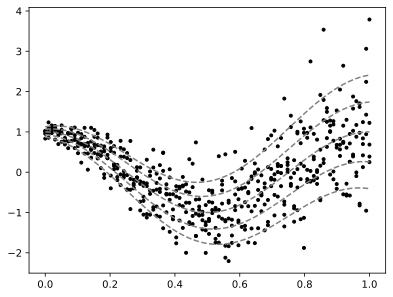

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Placing prior mean

We place prior mean for the median quantile.
Other quantiles will have prior means with constant offset to the median.

In [ ]:
class PriorMean(gpytorch.means.Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])

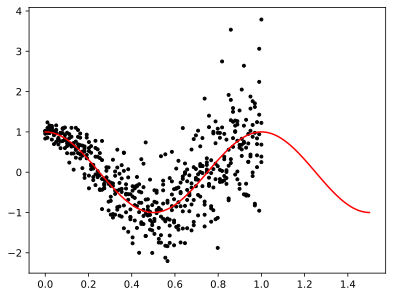

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), PriorMean()(x_pred).detach().cpu(), c="r")
plt.show()

## Define model and likelihood

To model the correlation between quantiles, the number of latent GP should be smaller than the number of tasks (= number of quantiles).

In [ ]:
class MyGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
        num_lower_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CenterGapLmcVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_latents=num_latents,
            num_lower_quantiles=num_lower_quantiles,
            num_lower_latents=num_lower_latents,
        )

        mean = CenterGapMean(
            PriorMean(batch_shape=torch.Size([1])),
            gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents - 1])),
            latent_dim=-1,
        )
        covar = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=D, batch_shape=torch.Size([num_latents])
            ),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, mean, covar, -1, num_lower_quantiles)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = 2
num_latents = 3
gp = MyGP(inducing_points, len(q), central_q_index, num_latents, num_latents // 2).to(
    device
)
likelihood = MultitaskCenterGapQuantileGPLikelihood(q, central_q_index).to(device)

## Training the model

In [ ]:
gp.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Estimating the result

Because center-gap architecture leads to non-analytic posterior of quantiles, we estimate the mean and credible interval of quantiles using Monte-Carlo sampling.

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles_mc(x_pred)
    lower_q, upper_q = gp.quantile_quantiles_mc(
        x_pred, torch.tensor([0.025, 0.975]).to(device)
    )

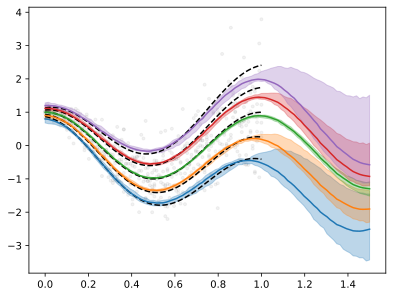

In [ ]:
colors = plt.cm.tab10.colors

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="k")

for i in range(len(q)):
    plt.plot(x_pred.cpu(), mean_q[:, i].cpu(), color=colors[i])
    plt.fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, i].cpu(),
        upper_q[:, i].cpu(),
        color=colors[i],
        alpha=0.3,
    )
plt.show()

### Predictive posterior of response variable

It is possible to evaluate the predictive posterior of response variable from quantile regression, just as ordinary Gaussian process regression.

Estimation from extreme quantiles are less credible than near-median quantiles.

In [ ]:
with torch.no_grad(), gpytorch.settings.num_likelihood_samples(1000):
    pp = likelihood.predictive_posterior(gp(x_pred))
pp_mean = pp.mean(dim=0)
pp_lower = pp.quantile(0.025, dim=0)
pp_upper = pp.quantile(0.975, dim=0)

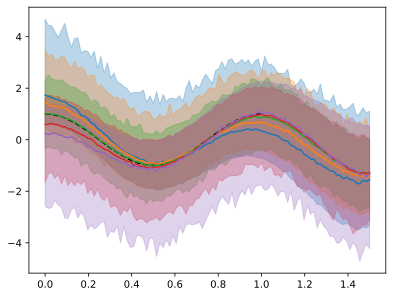

In [ ]:
plt.plot(x_range.cpu(), mean(x_range).cpu(), "--", c="k")

for i in range(len(q)):
    plt.plot(x_pred.cpu(), pp_mean[:, i].cpu(), color=colors[i])
    plt.fill_between(
        x_pred.cpu().squeeze(),
        pp_lower[:, i].cpu(),
        pp_upper[:, i].cpu(),
        color=colors[i],
        alpha=0.3,
    )
plt.show()